## LAB04 - Tarefa IV

## Avaliacao do hiperparametro `min_samples` no DBSCAN

Nesta atividade vamos avaliar o efeito do hiperparametro `min_samples`, chamado no enunciado de `Num_min`, no algoritmo DBSCAN.

Conforme solicitado no LAB04, o raio sera mantido fixo em `eps = 0.7` e serao testados os seguintes valores para `min_samples`: `5`, `10`, `19`, `20` e `25`.

Observacao: o arquivo `TarefaIV_Lab04.pdf` apresenta um exemplo de solucao usando uma base com `500` amostras e `4` centros. Neste notebook foi mantida a base do arquivo `Lab04Tarefa04`, com `1000` amostras e `8` centros.

## 1. Importacao das bibliotecas

O DBSCAN sera importado da biblioteca `scikit-learn`. Tambem serao usadas bibliotecas para geracao da base, visualizacao e calculo de metricas de avaliacao.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score

## 2. Geracao da base de dados

A base usada aqui segue o codigo do `Lab04Tarefa04`: `1000` amostras, `8` centros, `2` atributos e `random_state=800` para garantir reproducibilidade.

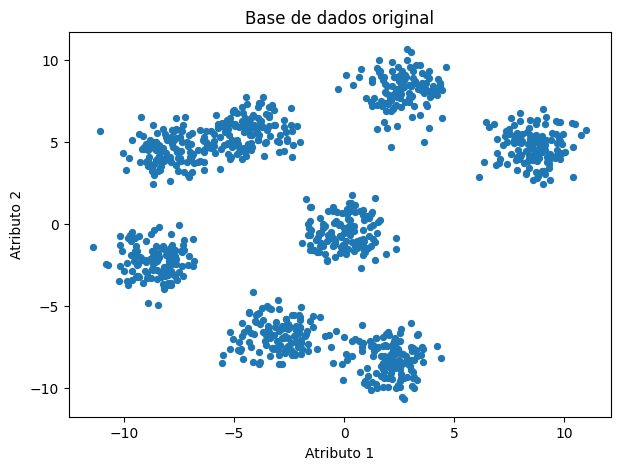

In [2]:
X, y = make_blobs(
    n_samples=1000,
    centers=8,
    n_features=2,
    random_state=800,
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=18)
plt.title("Base de dados original")
plt.xlabel("Atributo 1")
plt.ylabel("Atributo 2")
plt.show()

## 3. Funcoes auxiliares

As funcoes abaixo calculam a quantidade de clusters encontrados, a quantidade de pontos classificados como ruido e uma versao segura do indice de silhueta, ignorando pontos de ruido.

In [3]:
def count_clusters(labels):
    unique_labels = set(labels)
    return len(unique_labels - {-1})


def count_noise(labels):
    return int(np.sum(labels == -1))


def safe_silhouette_score(x, labels):
    valid = labels != -1
    valid_labels = labels[valid]

    if len(set(valid_labels)) < 2:
        return np.nan

    return silhouette_score(x[valid], valid_labels)

## 4. Execucao do DBSCAN para diferentes valores de `min_samples`

Nesta etapa, o valor de `eps` fica fixo em `0.7`, enquanto `min_samples` varia de acordo com o enunciado.

In [4]:
eps_fixo = 0.7
min_samples_test = [5, 10, 19, 20, 25]

results = []

for min_samples in min_samples_test:
    db = DBSCAN(
        eps=eps_fixo,
        min_samples=min_samples,
        metric="euclidean",
    )
    labels = db.fit_predict(X)

    results.append(
        {
            "min_samples": min_samples,
            "labels": labels,
            "n_clusters": count_clusters(labels),
            "n_noise": count_noise(labels),
            "noise_pct": 100 * count_noise(labels) / len(labels),
            "silhouette": safe_silhouette_score(X, labels),
            "ari": adjusted_rand_score(y, labels),
        }
    )

## 5. Visualizacao dos agrupamentos

Cada grafico mostra o resultado do DBSCAN para um valor diferente de `min_samples`. Os pontos em cinza representam ruido, ou seja, dados classificados com rotulo `-1`.

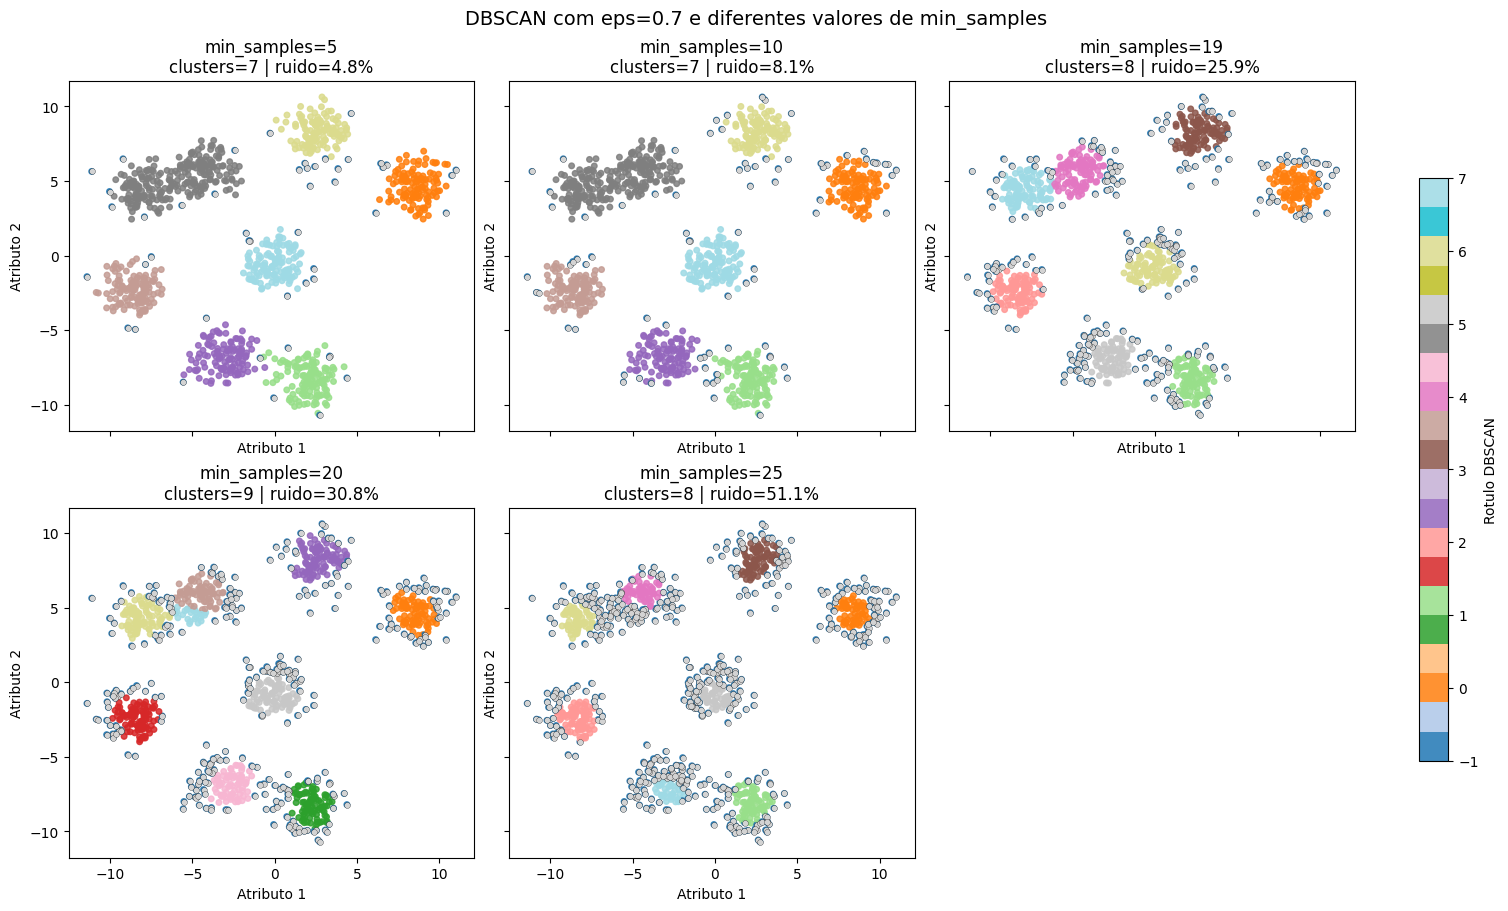

In [5]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = axes.ravel()

for ax, result in zip(axes, results):
    labels = result["labels"]
    scatter = ax.scatter(
        X[:, 0],
        X[:, 1],
        c=labels,
        cmap="tab20",
        s=16,
        alpha=0.85,
    )

    ax.scatter(
        X[labels == -1, 0],
        X[labels == -1, 1],
        c="lightgray",
        edgecolor="black",
        linewidth=0.2,
        s=18,
        label="ruido",
    )

    ax.set_title(
        "min_samples={}\nclusters={} | ruido={:.1f}%".format(
            result["min_samples"],
            result["n_clusters"],
            result["noise_pct"],
        )
    )
    ax.set_xlabel("Atributo 1")
    ax.set_ylabel("Atributo 2")

axes[-1].axis("off")
fig.colorbar(scatter, ax=axes[:-1], shrink=0.75, label="Rotulo DBSCAN")
fig.suptitle("DBSCAN com eps=0.7 e diferentes valores de min_samples", fontsize=14)
plt.show()

## 6. Tabela de resultados

A tabela resume o comportamento do algoritmo para cada valor testado. O ARI compara os rotulos encontrados pelo DBSCAN com os rotulos originais gerados pelo `make_blobs`.

In [6]:
print("min_samples | clusters | ruido | ruido(%) | silhouette | ARI")
print("-" * 60)

for result in results:
    silhouette = result["silhouette"]
    silhouette_text = "nan" if np.isnan(silhouette) else f"{silhouette:.4f}"

    print(
        "{:11d} | {:8d} | {:5d} | {:8.2f} | {:10s} | {:.4f}".format(
            result["min_samples"],
            result["n_clusters"],
            result["n_noise"],
            result["noise_pct"],
            silhouette_text,
            result["ari"],
        )
    )

min_samples | clusters | ruido | ruido(%) | silhouette | ARI
------------------------------------------------------------
          5 |        7 |    48 |     4.80 | 0.6974     | 0.8086
         10 |        7 |    81 |     8.10 | 0.7088     | 0.7672
         19 |        8 |   259 |    25.90 | 0.7343     | 0.5270
         20 |        9 |   308 |    30.80 | 0.7030     | 0.4112
         25 |        8 |   511 |    51.10 | 0.8190     | 0.1640


## 7. Escolha automatica do melhor valor

Como a base do `Lab04Tarefa04` foi gerada com `8` centros, o criterio abaixo prioriza resultados que recuperam uma quantidade de clusters mais proxima de `8`. Em seguida, usa o ARI, o indice de silhueta e a porcentagem de ruido como criterios de desempate.

In [7]:
expected_clusters = 8

best = max(
    results,
    key=lambda item: (
        -abs(item["n_clusters"] - expected_clusters),
        item["ari"],
        item["silhouette"] if not np.isnan(item["silhouette"]) else -1,
        -item["noise_pct"],
    ),
)

print(
    "Valor recomendado: min_samples={} | clusters={} | ruido={:.2f}% | ARI={:.4f}".format(
        best["min_samples"],
        best["n_clusters"],
        best["noise_pct"],
        best["ari"],
    )
)

Valor recomendado: min_samples=19 | clusters=8 | ruido=25.90% | ARI=0.5270


## 8. Conclusao

Com `eps = 0.7`, o aumento de `min_samples` torna o DBSCAN mais rigoroso. Valores baixos, como `5` e `10`, classificam poucos pontos como ruido, mas podem unir regioes proximas e reduzir a quantidade de clusters encontrados. Valores altos, como `20` e `25`, aumentam muito a quantidade de pontos classificados como ruido e podem fragmentar os agrupamentos.

Para a base do `Lab04Tarefa04`, gerada com `8` centros, o valor `min_samples = 19` foi o mais adequado entre os testados, pois recuperou `8` clusters sem descartar tantos pontos quanto `min_samples = 25`.

Se a base usada for a do exemplo `TarefaIV_Lab04.pdf`, com `500` amostras e `4` centros, a conclusao visual esperada muda: nesse caso, o exemplo recomenda `min_samples = 10`, por manter boa estabilidade dos clusters com baixa quantidade de ruido.